In [2]:
import pandas as pd
# Load dataset
df=pd.read_csv("wellness center_data.csv")

In [3]:
# Basic info
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CityCode               497 non-null    int64  
 1   WellnessCenterCode     492 non-null    object 
 2   Category               497 non-null    object 
 3   DoctorCount            497 non-null    int64  
 4   Latitude               480 non-null    float64
 5   Longitude              488 non-null    object 
 6   WellnessCentreName     0 non-null      float64
 7   CityName               497 non-null    object 
 8   WellnessCenterNumber   481 non-null    object 
 9   WellnessCenterAddress  492 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 39.0+ KB
None
CityCode                   0
WellnessCenterCode         5
Category                   0
DoctorCount                0
Latitude                  17
Longitude                  9
WellnessCentreName       497


In [17]:
df.head()

,CityCode,WellnessCenterCode,Category,DoctorCount,Latitude,Longitude,WellnessCentreName,CityName,WellnessCenterNumber,WellnessCenterAddress
0,10,AH06,Allopathy,0,23.035601,72.569460,Unknown,Ahmedabad,079-26577393,"3rd Floor, S.R.House, Opp. Mount Carmel Schoo..."
1,10,AH07,Allopathy,3,23.207968,72.648354,Unknown,Ahmedabad,079-23243433,"Sec-8, GH-1 A705/1,2,3 & 4, Opp. Sector 8 gar..."
2,10,AH10,Allopathy,1,23.022499,72.474210,Unknown,Ahmedabad,02717-243144,"AG Govt. Quarters,Block No A(1), QuarterSN 1 ..."
3,10,VDA,Allopathy,2,22.302678,73.224506,Unknown,Ahmedabad,0265-2415555,"Panigate Telephone exchange Compound, Ground f..."
4,11,ALA1,Ayurveda,0,25.449724,81.831098,Unknown,Prayagraj,0532-2561310,"2nd Floor, Sangam Place, Civil Lines, Prayagra..."


In [18]:
df.tail()

,CityCode,WellnessCenterCode,Category,DoctorCount,Latitude,Longitude,WellnessCentreName,CityName,WellnessCenterNumber,WellnessCenterAddress
492,30,PUA07,Ayurveda,2,18.494900,73.860015,Unknown,Pune,NaN,Ground Floor
493,31,RA1,Allopathy,4,23.344479,85.318386,Unknown,Ranchi,0651-2481901,"New A.G. Colony Doranda, Ranchi, Jharkhand"
494,32,IM2,Homeopathy,1,24.798098,93.951660,Unknown,Shillong,0385-2442104,"CMO In-chare, CGHS WC, Imphal,Gr. Floor Buildi..."
495,33,COH1,Allopathy,2,9.975109,76.295392,Unknown,Trivandrum,0484- 2954646,"O/o CMO I/C, E-01/ Type V, BSNL quarters"
496,33,TR3,Allopathy,3,8.498841,76.947349,Unknown,Trivandrum,0471-2471143,"O/o CMO I/C, P S Towers, Tutors Lane, Statue,..."


In [20]:
df.shape

(496, 10)

In [22]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
492    False
493    False
494    False
495    False
496    False
Length: 496, dtype: bool

In [23]:
print(df.isnull().sum())

CityCode                  0
WellnessCenterCode        5
Category                  0
DoctorCount               0
Latitude                 17
Longitude                16
WellnessCentreName        0
CityName                  0
WellnessCenterNumber     16
WellnessCenterAddress     5
dtype: int64


In [4]:
# Clean column names
df.columns=df.columns.str.strip().str.replace(" ","_")

In [5]:
#Clean Longitude (remove newline)

df['Longitude'] = df['Longitude'].astype(str).str.replace('\n', '').str.strip()

In [7]:
#Convert to float
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

In [8]:
 #Convert Data Types

df['CityCode'] = pd.to_numeric(df['CityCode'], errors='coerce')
df['DoctorCount'] = pd.to_numeric(df['DoctorCount'], errors='coerce')
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')

In [10]:
df.loc[:, 'WellnessCentreName'] = df['WellnessCentreName'].fillna("Unknown")
df.loc[:, 'Category'] = df['Category'].fillna("Unknown")

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
#Optional: Drop unwanted column
df_cleaned = df.drop(columns=['ContactNumber', 'Address'], errors='ignore')

In [13]:
 #Save Clean Data

df_cleaned.to_csv("cleaned_wellness_data.csv", index=False)

print("✅ Data Cleaned Successfully")

✅ Data Cleaned Successfully


### Doctor Distribution

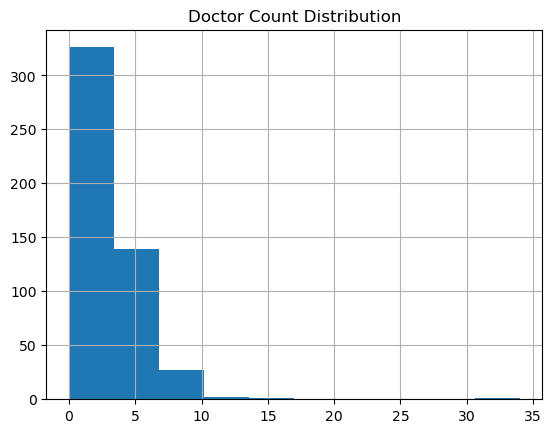

In [14]:
import matplotlib.pyplot as plt

df_cleaned['DoctorCount'].hist()
plt.title("Doctor Count Distribution")
plt.show()

### Category Analysis

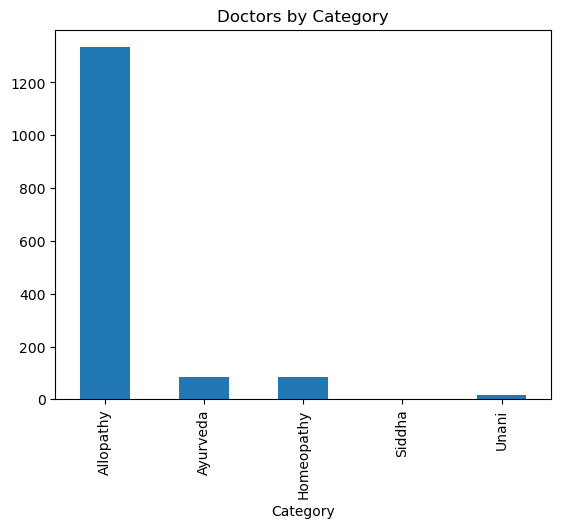

In [15]:
df_cleaned.groupby('Category')['DoctorCount'].sum().plot(kind='bar')
plt.title("Doctors by Category")
plt.show()

### Top Cities

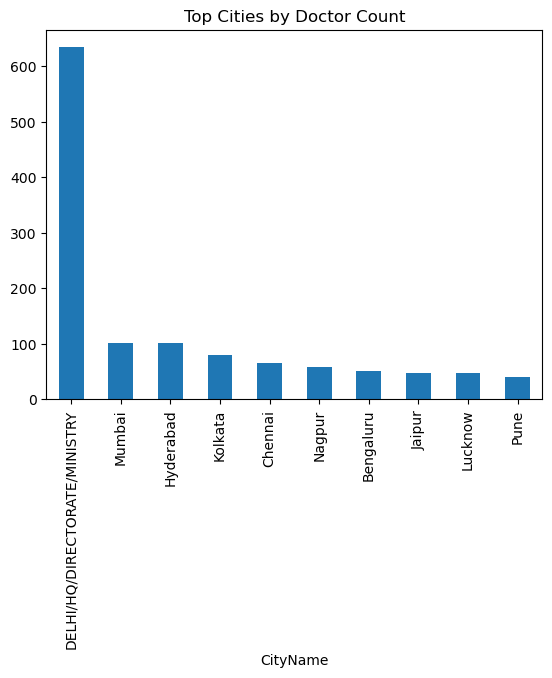

In [16]:
df_cleaned.groupby('CityName')['DoctorCount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Cities by Doctor Count")
plt.show()

In [24]:
df.to_csv("Wellness Centers data analyst")